In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\Sam\Desktop\Spotify_Genre_Segmentation\data\processed\spotify_cleaned.csv")

In [3]:

# Select important audio features for clustering
features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness",
            "valence", "tempo"]

In [4]:

X = df[features]

In [5]:

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

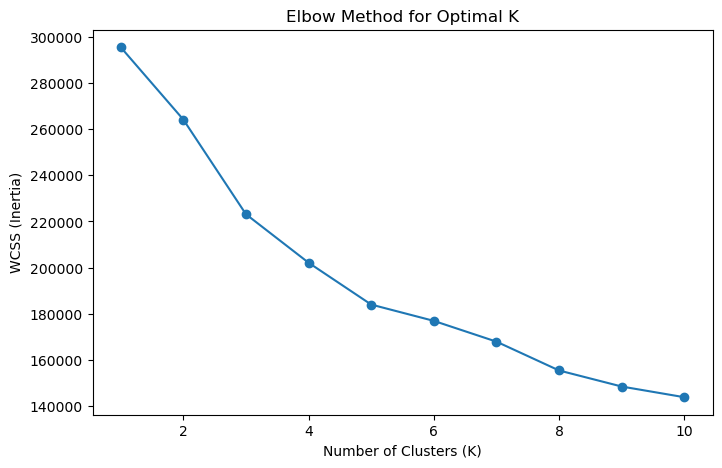

In [6]:

# -------------------------------
# 1. Elbow Method (Find best K)
# -------------------------------
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.show()

In [7]:

# -------------------------------
# 2. Train KMeans with best K
# -------------------------------
k = 5   # Change this based on elbow graph
kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(df["cluster"].value_counts())

cluster
1    11606
0     9171
2     4894
4     4610
3     2552
Name: count, dtype: int64


In [9]:

# Save clustered dataset
df.to_csv(r"C:\Users\Sam\Desktop\Spotify_Genre_Segmentation\data\output\spotify_clustered.csv", index=False)
print("✅ Clustered dataset saved as spotify_clustered.csv")

✅ Clustered dataset saved as spotify_clustered.csv
